# Simulated Data Signal Visualization

This notebook generates one synthetic dataset using the same default signal specification pattern as Stage 8 simulation and visualizes signal distributions by type and effect size.

In [1]:
from pathlib import Path
import sys

from matplotlib.colors import to_rgba
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

REPO_ROOT

WindowsPath('C:/Programmering/exjobb/MSc26_Proteomics')

In [2]:
from src.simulation import generate_simulated_dataset

from src.styles import ARDS_COLORS

EFFECT_SIZES = [0.3, 0.6, 1.0]
SIGNAL_TYPES = ["linear", "bounded_variance", "u_shape", "threshold"]
SIGNALS_PER_TYPE = 1


def build_default_signal_specs(
    effect_sizes: list[float],
    signals_per_type: int,
) -> list[dict[str, object]]:
    specs: list[dict[str, object]] = []
    for effect in effect_sizes:
        for signal_type in SIGNAL_TYPES:
            specs.append(
                {
                    "signal_type": signal_type,
                    "effect_size": float(effect),
                    "n_features": int(signals_per_type),
                }
            )
        specs.append(
            {
                "signal_type": "xor_pair",
                "effect_size": float(effect),
                "n_pairs": int(signals_per_type),
            }
        )
    return specs


signal_specs = build_default_signal_specs(
    effect_sizes=EFFECT_SIZES,
    signals_per_type=SIGNALS_PER_TYPE,
)

print(f"Built {len(signal_specs)} signal specs.")
signal_specs[:5]

Built 15 signal specs.


[{'signal_type': 'linear', 'effect_size': 0.3, 'n_features': 1},
 {'signal_type': 'bounded_variance', 'effect_size': 0.3, 'n_features': 1},
 {'signal_type': 'u_shape', 'effect_size': 0.3, 'n_features': 1},
 {'signal_type': 'threshold', 'effect_size': 0.3, 'n_features': 1},
 {'signal_type': 'xor_pair', 'effect_size': 0.3, 'n_pairs': 1}]

In [3]:
N = 5000
P = 100
CLASS_PREVALENCE = 0.2
SEED = 42

X, y, ground_truth = generate_simulated_dataset(
    n=N,
    p=P,
    class_prevalence=CLASS_PREVALENCE,
    signal_specs=signal_specs,
    seed=SEED,
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class counts (0, 1): {np.bincount(y)}")
print("Ground-truth keys:")
print(sorted(ground_truth.keys()))

X shape: (5000, 100)
y shape: (5000,)
Class counts (0, 1): [4000 1000]
Ground-truth keys:
['all_signal_indices', 'block_size', 'blocks', 'bounded_variance', 'by_type_effect', 'feature_block', 'linear', 'noise_indices', 'signal_records', 'threshold', 'u_shape', 'xor_pair']


In [4]:
effect_sizes = sorted(float(e) for e in EFFECT_SIZES)
all_signal_types = SIGNAL_TYPES + ["xor_pair"]

by_type_effect_raw = ground_truth.get("by_type_effect", {})
by_type_effect: dict[str, dict[float, list[int]]] = {}

for signal_type in all_signal_types:
    effect_map = by_type_effect_raw.get(signal_type, {})
    by_type_effect[signal_type] = {
        float(effect): [int(i) for i in indices]
        for effect, indices in effect_map.items()
    }

xor_records_by_effect: dict[float, list[tuple[int, int]]] = {effect: [] for effect in effect_sizes}
for record in ground_truth.get("signal_records", []):
    if str(record.get("signal_type")) != "xor_pair":
        continue
    effect = float(record.get("effect_size"))
    pair = tuple(int(i) for i in record.get("indices", []))
    if effect in xor_records_by_effect and len(pair) == 2:
        xor_records_by_effect[effect].append(pair)

summary_counts = {
    signal_type: {
        effect: len(by_type_effect[signal_type].get(effect, []))
        for effect in effect_sizes
    }
    for signal_type in all_signal_types
}
summary_counts

{'linear': {0.3: 1, 0.6: 1, 1.0: 1},
 'bounded_variance': {0.3: 1, 0.6: 1, 1.0: 1},
 'u_shape': {0.3: 1, 0.6: 1, 1.0: 1},
 'threshold': {0.3: 1, 0.6: 1, 1.0: 1},
 'xor_pair': {0.3: 2, 0.6: 2, 1.0: 2}}

In [5]:
FONT_SIZE_TITLE = 22
FONT_SIZE_AXIS_LABEL = 20
FONT_SIZE_LEGEND = 18


def plot_signal_histograms(signal_type: str, effects: list[float]) -> None:
    fig, axes = plt.subplots(
        1,
        len(effects),
        figsize=(5 * len(effects), 4),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    c0 = "#7570b3"
    c1 = "#d95f02"

    for ax, effect in zip(axes, effects):
        indices = by_type_effect.get(signal_type, {}).get(effect, [])

        if not indices:
            ax.set_title(f"effect={effect} (no features)", fontsize=FONT_SIZE_TITLE)
            ax.set_xlabel("Feature value", fontsize=FONT_SIZE_AXIS_LABEL)
            continue

        representative_idx = int(indices[0])
        x0 = X[y == 0, representative_idx]
        x1 = X[y == 1, representative_idx]

        combined = np.concatenate([x0, x1])
        bins = np.histogram_bin_edges(combined, bins=30)

        ax.hist(
            x0,
            bins=bins,
            density=True,
            label="y=0",
            facecolor=to_rgba(c0, 0.55),
            #edgecolor=to_rgba(c0, 1.0),
            #histtype="stepfilled",
        )
        ax.hist(
            x1,
            bins=bins,
            density=True,
            label="y=1",
            facecolor=to_rgba(c1, 0.55),
            #edgecolor=to_rgba(c1, 1.0),
            #histtype="stepfilled",
        )
        ax.tick_params(axis='both', labelsize=16)
        ax.set_title(f"Effect={effect}", fontsize=FONT_SIZE_TITLE)
        ax.set_xlabel("Feature value", fontsize=FONT_SIZE_AXIS_LABEL)
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("Density", fontsize=FONT_SIZE_AXIS_LABEL)

    fig.tight_layout()

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper right",
            bbox_to_anchor=(0.985, 0.985),
            fontsize=FONT_SIZE_LEGEND,
            frameon=True,
        )

    #fig.suptitle(f"{signal_type.replace('_', ' ').title()} Signals", y=0.95, fontsize=14)
    
    # Save figure as PDF
    output_dir = Path("../results/figs/sim_val")
    #output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"sim_{signal_type}.pdf"
    fig.savefig(output_path, format="pdf", dpi=300)
    print(f"Saved figure to {output_path}")
    
    print(f"Plotting histograms for {signal_type} signals with effects: {effects}")
    plt.show()

Saved figure to ..\results\figs\sim_val\sim_linear.pdf
Plotting histograms for linear signals with effects: [0.3, 0.6, 1.0]


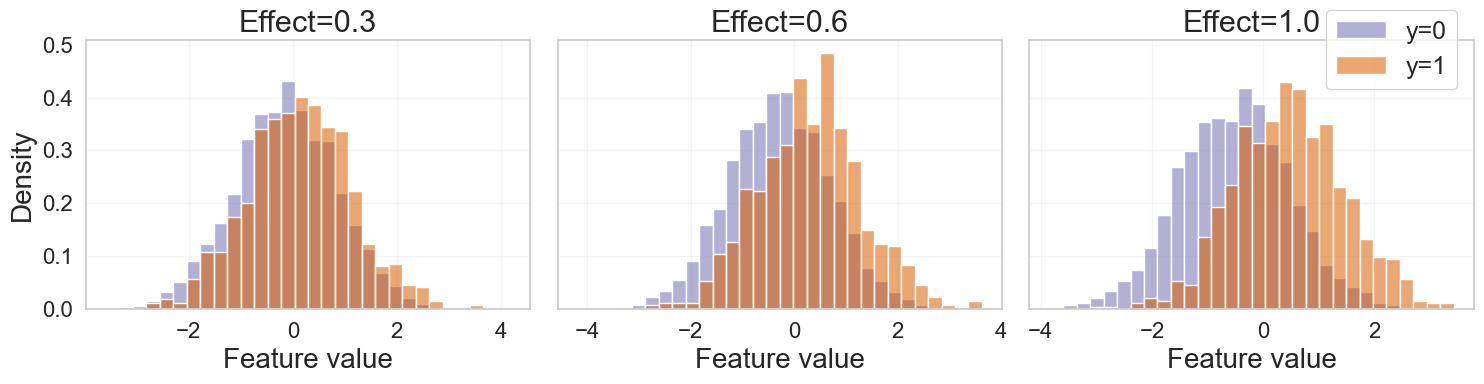

Saved figure to ..\results\figs\sim_val\sim_bounded_variance.pdf
Plotting histograms for bounded_variance signals with effects: [0.3, 0.6, 1.0]


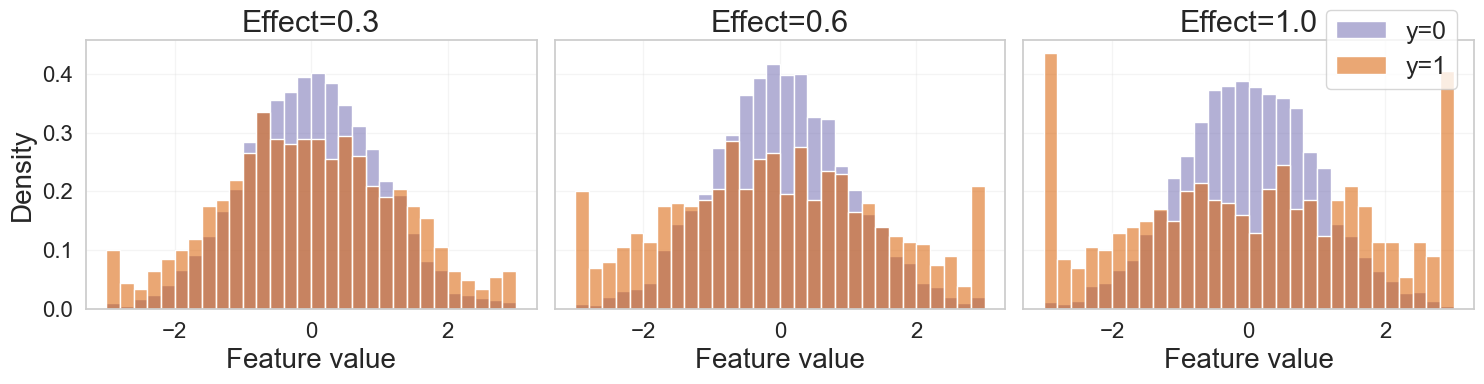

Saved figure to ..\results\figs\sim_val\sim_u_shape.pdf
Plotting histograms for u_shape signals with effects: [0.3, 0.6, 1.0]


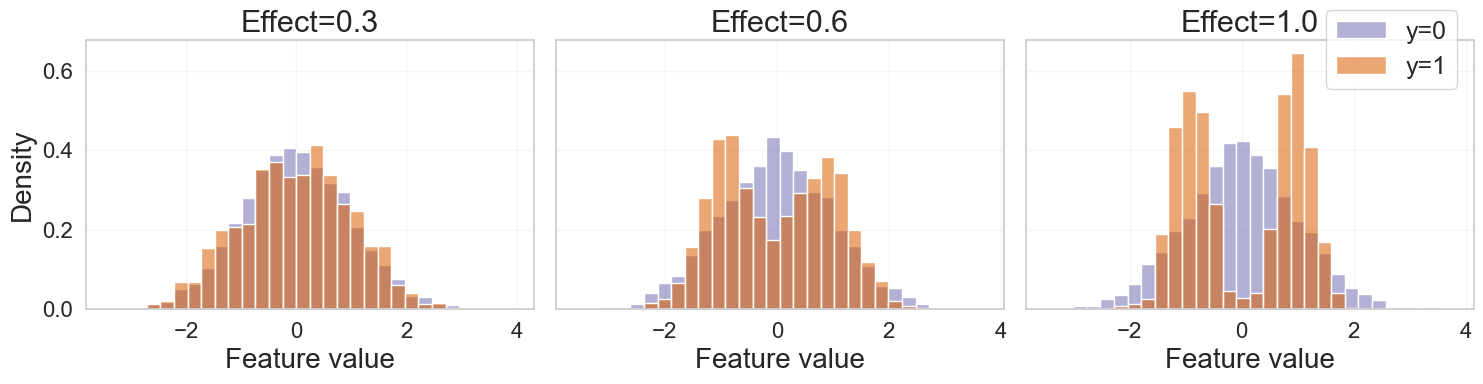

Saved figure to ..\results\figs\sim_val\sim_threshold.pdf
Plotting histograms for threshold signals with effects: [0.3, 0.6, 1.0]


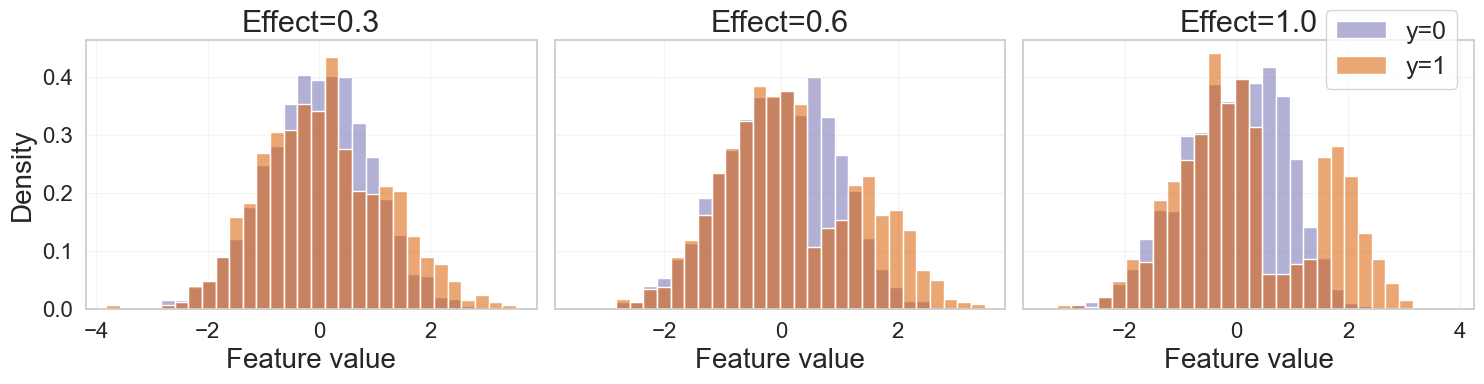

In [6]:
for signal_type in SIGNAL_TYPES:
    plot_signal_histograms(signal_type=signal_type, effects=effect_sizes)

Saved figure to ..\results\figs\sim_val\sim_XOR.pdf


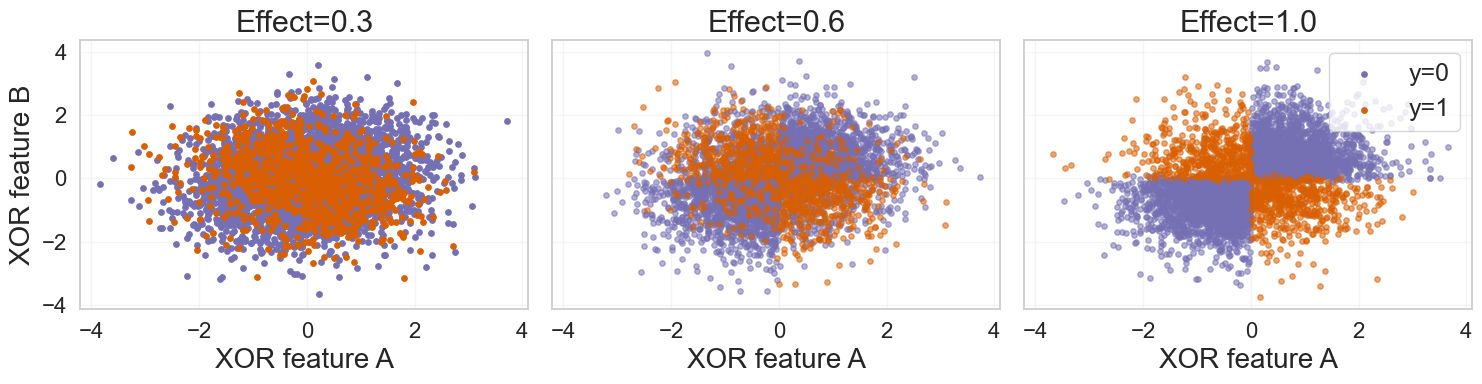

In [7]:
def plot_xor_scatter(effects: list[float]) -> None:
    fig, axes = plt.subplots(
        1,
        len(effects),
        figsize=(5 * len(effects), 4),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    selected_pairs = {
        effect: (pairs[0] if pairs else None)
        for effect, pairs in xor_records_by_effect.items()
    }

    all_x = []
    all_y = []
    for effect in effects:
        pair = selected_pairs.get(effect)
        if pair is None:
            continue
        idx_a, idx_b = pair
        all_x.append(X[:, idx_a])
        all_y.append(X[:, idx_b])

    if all_x and all_y:
        x_min = min(arr.min() for arr in all_x)
        x_max = max(arr.max() for arr in all_x)
        y_min = min(arr.min() for arr in all_y)
        y_max = max(arr.max() for arr in all_y)
        x_pad = 0.05 * (x_max - x_min + 1e-9)
        y_pad = 0.05 * (y_max - y_min + 1e-9)
    else:
        x_min, x_max = -3.0, 3.0
        y_min, y_max = -3.0, 3.0
        x_pad = 0.0
        y_pad = 0.0

    cls0 = y == 0
    cls1 = y == 1

    for ax, effect in zip(axes, effects):
        pair = selected_pairs.get(effect)

        if pair is None:
            ax.set_title(f"effect={effect} (no pairs)", fontsize=FONT_SIZE_TITLE)
            ax.set_xlabel("XOR feature A", fontsize=FONT_SIZE_AXIS_LABEL)
            continue

        c0 = "#7570b3"
        c1 = "#d95f02"

        idx_a, idx_b = pair
        ax.scatter(X[cls0, idx_a], X[cls0, idx_b], s=15, label="y=0", color=to_rgba(c0, 0.55))
        ax.scatter(X[cls1, idx_a], X[cls1, idx_b], s=15, label="y=1", color=to_rgba(c1, 0.55))
        ax.tick_params(axis='both', labelsize=16)

        ax.set_title(f"Effect={effect}", fontsize=FONT_SIZE_TITLE)
        ax.set_xlabel("XOR feature A", fontsize=FONT_SIZE_AXIS_LABEL)
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("XOR feature B", fontsize=FONT_SIZE_AXIS_LABEL)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        for h in handles:
            if hasattr(h, "set_alpha"):
                try:
                    h.set_alpha(1.0)
                except Exception:
                    pass
        axes[-1].legend(
            handles,
            labels,
            loc="upper right",
            fontsize=FONT_SIZE_LEGEND,
            frameon=True,
        )

    fig.tight_layout()

    output_dir = Path("../results/figs/sim_val")
    #output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"sim_XOR.pdf"
    fig.savefig(output_path, format="pdf", dpi=300)
    print(f"Saved figure to {output_path}")

    #fig.suptitle("XOR Pair Signals", y=0.95, fontsize=14)
    plt.show()


plot_xor_scatter(effect_sizes)

## Block-diagonal correlation structure

Re-generate the dataset with `block_size=20` and visualise the empirical correlation matrix. Each block uses a single shared off-diagonal `rho ~ U(0.3, 0.8)`, sampled once per block.

In [8]:
BLOCK_SIZE = 20
N_LARGE = 5000  # larger n so the empirical correlation is close to the population one
P = 100

X_blk, y_blk, gt_blk = generate_simulated_dataset(
    n=N_LARGE,
    p=P,
    class_prevalence=CLASS_PREVALENCE,
    signal_specs=signal_specs,
    seed=SEED,
    block_size=BLOCK_SIZE,
)

print(f"X shape: {X_blk.shape}")
print(f"block_size: {gt_blk['block_size']}, n_blocks: {len(gt_blk['blocks'])}")
print(f"feature_block (head): {gt_blk['feature_block'][:5]} ... tail: {gt_blk['feature_block'][-5:]}")

X shape: (5000, 100)
block_size: 20, n_blocks: 5
feature_block (head): [0, 0, 0, 0, 0] ... tail: [4, 4, 4, 4, 4]


Saved figure to ..\results\figs\sim_val\sim_empirical_correlation.pdf


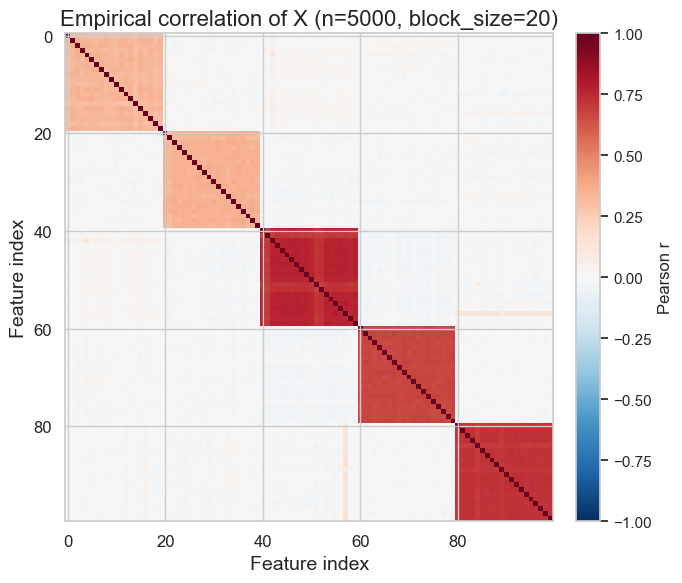

In [9]:
corr = np.corrcoef(X_blk.T)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1.0, vmax=1.0)

#n_blocks = P // BLOCK_SIZE
#for b in range(1, n_blocks):
#    boundary = b * BLOCK_SIZE - 0.5
#    ax.axhline(boundary, color="black", linewidth=0.6)
#    ax.axvline(boundary, color="black", linewidth=0.6)

ax.set_title(f"Empirical correlation of X (n={N_LARGE}, block_size={BLOCK_SIZE})", fontsize=16)
ax.set_xlabel("Feature index", fontsize=14)
ax.set_ylabel("Feature index", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
fig.tight_layout()

output_dir = Path("../results/figs/sim_val")
#output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"sim_empirical_correlation.pdf"
fig.savefig(output_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved figure to {output_path}")

plt.show()

In [10]:
# Per-block summary: mean off-diagonal correlation within each block,
# and the max absolute off-block correlation per block (should be near zero).
rows = []
for b, idx_list in enumerate(gt_blk["blocks"]):
    idx = np.array(idx_list)
    sub = corr[np.ix_(idx, idx)]
    off_diag = sub[~np.eye(len(idx), dtype=bool)]
    other = np.setdiff1d(np.arange(P), idx)
    cross = corr[np.ix_(idx, other)]
    rows.append(
        {
            "block": b,
            "size": len(idx),
            "within_mean_r": float(off_diag.mean()),
            "within_min_r": float(off_diag.min()),
            "within_max_r": float(off_diag.max()),
            "max_abs_cross_r": float(np.abs(cross).max()),
        }
    )

pd.DataFrame(rows)

,block,size,within_mean_r,within_min_r,within_max_r,max_abs_cross_r
0,0,20,0.329223,0.289184,0.365984,0.124200
1,1,20,0.348415,0.307583,0.378232,0.041723
2,2,20,0.751120,0.682358,0.791474,0.172522
3,3,20,0.669475,0.650216,0.686132,0.050431
4,4,20,0.719865,0.691345,0.737126,0.172522
